In [17]:
import torch 
import torch.nn as nn
import numpy as np
from torch.nn import Parameter
import torch.nn.functional as F
import torch.optim as optim
from sklearn import metrics
import os
from tqdm import tqdm


from torch_geometric.utils import to_undirected, subgraph
from torch_geometric.data import Data, Batch, DataLoader

from config import config_train, config_test
from data_process import data_process_all_chrom, data_process

import models
from sampler import *
from aggregator import MaxminMeanAggregator

import utils
from batch import load_val

/public/home/wuyy/miniconda3/envs/torch/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [18]:
import pickle

In [3]:
def model_eval(data, test_batchloader, model, Aggregator):
    model.eval()
    Aggregator.eval()
    with torch.no_grad():
        total_pred = []
        test_label = []
        num_data = 0

        v = model(data.x, data.edge_index, data.edge_attr)
        
        while True :
            hedges, labels, is_last = test_batchloader.next()
            batch_size = len(hedges)
            num_data+=batch_size
            for hedge in hedges :
                embeddings = v[hedge]
                #pred, _ = Aggregator(embeddings)
                max_min_dist = torch.max(hedge) - torch.min(hedge)
                pred, _ = Aggregator(max_min_dist,embeddings)
                total_pred.append(pred.detach())
            test_label.append(labels.detach())
            
            if is_last :
                break
        total_pred = torch.stack(total_pred)       
        total_pred = total_pred.squeeze()
        test_label = torch.cat(test_label, dim=0)
        

    return total_pred.tolist(), test_label.tolist()

In [4]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [5]:
dim_edge = 400
dim_vertex = 400

alpha_e = 0
alpha_v = 0

input_dim = 15 #features_num

n_layers = 1

size = 1000
nv = size

memory_size = 0

lr = 0.00004

bs = 512

memory_size = 0
clip = 0.01
n_layers = 3


In [6]:
model_dir = 'models/GM12878/'

model = models.GCNEncoder(input_dim, dim_vertex, dim_vertex, n_layers)

model.to(device)

if model_dir:
    model.load_state_dict(torch.load(model_dir+"model_epoch_7"))

cls_layers = [dim_vertex*2+2, dim_vertex, 256, 128, 32, 8, 1] #[dim_vertex, 128, 8, 1]
Aggregator = MaxminMeanAggregator(dim_vertex, cls_layers)#MaxminAggregator(dim_vertex, cls_layers)
Aggregator.to(device)

if model_dir:
    Aggregator.load_state_dict(torch.load(model_dir+"Aggregator_epoch_7"))

In [ ]:
order_results = {}

for i in range(3,11):

    mns_aucs = []
    mns_aps = []
    sns_aucs = []
    sns_aps = []
    cns_aucs = []
    cns_aps = []
    rwcns_aucs = []
    rwcns_aps = []
    
    
    for chr_name in ["chr14", "chr22", "chrX"]:

        with open("chrom_data/GM12878/"+chr_name+"_sliding_data","rb") as f:
            sliding_data = pickle.load(f)

        for data in sliding_data:
    
            if len(data.hyper_edge) < bs:
                continue

            data = data.to(device)
        
            hyper_edge = []
            for h in data.hyper_edge:
                if len(h) == i:
                    hyper_edge.append(h)
                    
            mns = []
            for h in data.mns:
                if len(h) == i:
                    mns.append(h)
                    
            sns = []
            for h in data.sns:
                if len(h) == i:
                    sns.append(h)
                    
            cns = []
            for h in data.cns:
                if len(h) == i:
                    cns.append(h)
            
            
            if len(hyper_edge) < bs or len(mns) < bs or len(sns) < bs or len(cns) < bs:
                continue
        
            test_batchloader = load_val(hyper_edge, bs, device, label="pos")
            val_pred_pos, total_label_pos = model_eval(data, test_batchloader, model, Aggregator)
                
            test_batchloader = load_val(mns, bs, device, label="mns")
            val_pred_mns, total_label_mns = model_eval(data, test_batchloader, model, Aggregator)
            mns_auc = metrics.roc_auc_score(total_label_mns+total_label_pos, val_pred_mns+val_pred_pos)
            mns_ap = metrics.average_precision_score(total_label_mns+total_label_pos, val_pred_mns+val_pred_pos)
        
            test_batchloader = load_val(sns, bs, device, label="sns")
            val_pred_sns, total_label_sns = model_eval(data, test_batchloader, model, Aggregator)
            sns_auc = metrics.roc_auc_score(total_label_sns+total_label_pos, val_pred_sns+val_pred_pos)
            sns_ap = metrics.average_precision_score(total_label_sns+total_label_pos, val_pred_sns+val_pred_pos)        
        
            test_batchloader = load_val(cns, bs, device, label="cns")
            val_pred_cns, total_label_cns = model_eval(data, test_batchloader, model, Aggregator)
            cns_auc = metrics.roc_auc_score(total_label_cns+total_label_pos, val_pred_cns+val_pred_pos)
            cns_ap = metrics.average_precision_score(total_label_cns+total_label_pos, val_pred_cns+val_pred_pos)        
    
    
            mns_aucs.append(mns_auc)
            mns_aps.append(mns_ap)
            sns_aucs.append(sns_auc)
            sns_aps.append(sns_ap)
            cns_aucs.append(cns_auc)
            cns_aps.append(cns_ap)
    
    
    order_results[i] = [mns_aucs, sns_aucs, cns_aucs, mns_aps, sns_aps, cns_aps]

    mns_aucs = np.mean(mns_aucs)
    mns_aps = np.mean(mns_aps)
    sns_aucs = np.mean(sns_aucs)
    sns_aps = np.mean(sns_aps)
    cns_aucs = np.mean(cns_aucs)
    cns_aps = np.mean(cns_aps)


    print("Order:"+str(i))
    print("Val mns AUC:"+str(mns_aucs)+",Val mns AP:"+str(mns_aps))
    print("Val sns AUC:"+str(sns_aucs)+",Val sns AP:"+str(sns_aps))
    print("Val cns AUC:"+str(cns_aucs)+",Val cns AP:"+str(cns_aps))
    

In [ ]:
# GM12878_order = order_results

# with open("GM12878_order","wb") as f:
#     pickle.dump(GM12878_order, f)

In [ ]:
model_dir = 'models/K562/'

model = models.GCNEncoder(input_dim, dim_vertex, dim_vertex, n_layers)

model.to(device)

if model_dir:
    model.load_state_dict(torch.load(model_dir+"model_epoch_9"))

cls_layers = [dim_vertex*2+2, dim_vertex, 256, 128, 32, 8, 1] #[dim_vertex, 128, 8, 1]
Aggregator = MaxminMeanAggregator(dim_vertex, cls_layers)#MaxminAggregator(dim_vertex, cls_layers)
Aggregator.to(device)

if model_dir:
    Aggregator.load_state_dict(torch.load(model_dir+"Aggregator_epoch_9"))

In [ ]:
order_results = {}

for i in range(3,11):

    mns_aucs = []
    mns_aps = []
    sns_aucs = []
    sns_aps = []
    cns_aucs = []
    cns_aps = []
    rwcns_aucs = []
    rwcns_aps = []
    
    
    for chr_name in ["chr14", "chr22", "chrX"]:

        with open("chrom_data/K562/"+chr_name+"_sliding_data","rb") as f:
            sliding_data = pickle.load(f)

        for data in sliding_data:
    
            if len(data.hyper_edge) < bs:
                continue

            data = data.to(device)
        
            hyper_edge = []
            for h in data.hyper_edge:
                if len(h) == i:
                    hyper_edge.append(h)
                    
            mns = []
            for h in data.mns:
                if len(h) == i:
                    mns.append(h)
                    
            sns = []
            for h in data.sns:
                if len(h) == i:
                    sns.append(h)
                    
            cns = []
            for h in data.cns:
                if len(h) == i:
                    cns.append(h)
            
            
            if len(hyper_edge) < bs or len(mns) < bs or len(sns) < bs or len(cns) < bs:
                continue
        
            test_batchloader = load_val(hyper_edge, bs, device, label="pos")
            val_pred_pos, total_label_pos = model_eval(data, test_batchloader, model, Aggregator)
                
            test_batchloader = load_val(mns, bs, device, label="mns")
            val_pred_mns, total_label_mns = model_eval(data, test_batchloader, model, Aggregator)
            mns_auc = metrics.roc_auc_score(total_label_mns+total_label_pos, val_pred_mns+val_pred_pos)
            mns_ap = metrics.average_precision_score(total_label_mns+total_label_pos, val_pred_mns+val_pred_pos)
        
            test_batchloader = load_val(sns, bs, device, label="sns")
            val_pred_sns, total_label_sns = model_eval(data, test_batchloader, model, Aggregator)
            sns_auc = metrics.roc_auc_score(total_label_sns+total_label_pos, val_pred_sns+val_pred_pos)
            sns_ap = metrics.average_precision_score(total_label_sns+total_label_pos, val_pred_sns+val_pred_pos)        
        
            test_batchloader = load_val(cns, bs, device, label="cns")
            val_pred_cns, total_label_cns = model_eval(data, test_batchloader, model, Aggregator)
            cns_auc = metrics.roc_auc_score(total_label_cns+total_label_pos, val_pred_cns+val_pred_pos)
            cns_ap = metrics.average_precision_score(total_label_cns+total_label_pos, val_pred_cns+val_pred_pos)        
    
    
            mns_aucs.append(mns_auc)
            mns_aps.append(mns_ap)
            sns_aucs.append(sns_auc)
            sns_aps.append(sns_ap)
            cns_aucs.append(cns_auc)
            cns_aps.append(cns_ap)
    
    
    order_results[i] = [mns_aucs, sns_aucs, cns_aucs, mns_aps, sns_aps, cns_aps]

    mns_aucs = np.mean(mns_aucs)
    mns_aps = np.mean(mns_aps)
    sns_aucs = np.mean(sns_aucs)
    sns_aps = np.mean(sns_aps)
    cns_aucs = np.mean(cns_aucs)
    cns_aps = np.mean(cns_aps)


    print("Order:"+str(i))
    print("Val mns AUC:"+str(mns_aucs)+",Val mns AP:"+str(mns_aps))
    print("Val sns AUC:"+str(sns_aucs)+",Val sns AP:"+str(sns_aps))
    print("Val cns AUC:"+str(cns_aucs)+",Val cns AP:"+str(cns_aps))
    

In [ ]:
# K562_order = order_results

# with open("K562_order","wb") as f:
#     pickle.dump(K562_order, f)

In [19]:
import csv

# 初始化空数组变量
mns_auc = []
mns_ap = []
sns_auc = []
sns_ap = []
cns_auc = []
cns_ap = []

with open('GM12878_different_order.csv', newline='') as csvfile:
    reader = csv.reader(csvfile)
    for row in reader:
        if row[0].startswith('Val'):
            if 'mns AUC' in row[0]:
                mns_auc.append(float(row[1]))
            if 'mns AP' in row[2]:
                mns_ap.append(float(row[3]))  # AP值在第四列
            if 'sns AUC' in row[0]:
                sns_auc.append(float(row[1]))
            if 'sns AP' in row[2]:
                sns_ap.append(float(row[3]))  # AP值在第四列
            if 'cns AUC' in row[0]:
                cns_auc.append(float(row[1]))
            if 'cns AP' in row[2]:
                cns_ap.append(float(row[3]))  # AP值在第四列
                


gmns_auc = mns_auc
gmns_ap = mns_ap
gsns_auc = sns_auc
gsns_ap = sns_ap
gcns_auc = cns_auc
gcns_ap = cns_ap


In [20]:
import csv

# 初始化空数组变量
mns_auc = []
mns_ap = []
sns_auc = []
sns_ap = []
cns_auc = []
cns_ap = []

with open('K562_different_order.csv', newline='') as csvfile:
    reader = csv.reader(csvfile)
    for row in reader:
        if row[0].startswith('Val'):
            if 'mns AUC' in row[0]:
                mns_auc.append(float(row[1]))
            if 'mns AP' in row[2]:
                mns_ap.append(float(row[3]))  # AP值在第四列
            if 'sns AUC' in row[0]:
                sns_auc.append(float(row[1]))
            if 'sns AP' in row[2]:
                sns_ap.append(float(row[3]))  # AP值在第四列
            if 'cns AUC' in row[0]:
                cns_auc.append(float(row[1]))
            if 'cns AP' in row[2]:
                cns_ap.append(float(row[3]))  # AP值在第四列
                


kmns_auc = mns_auc
kmns_ap = mns_ap
ksns_auc = sns_auc
ksns_ap = sns_ap
kcns_auc = cns_auc
kcns_ap = cns_ap


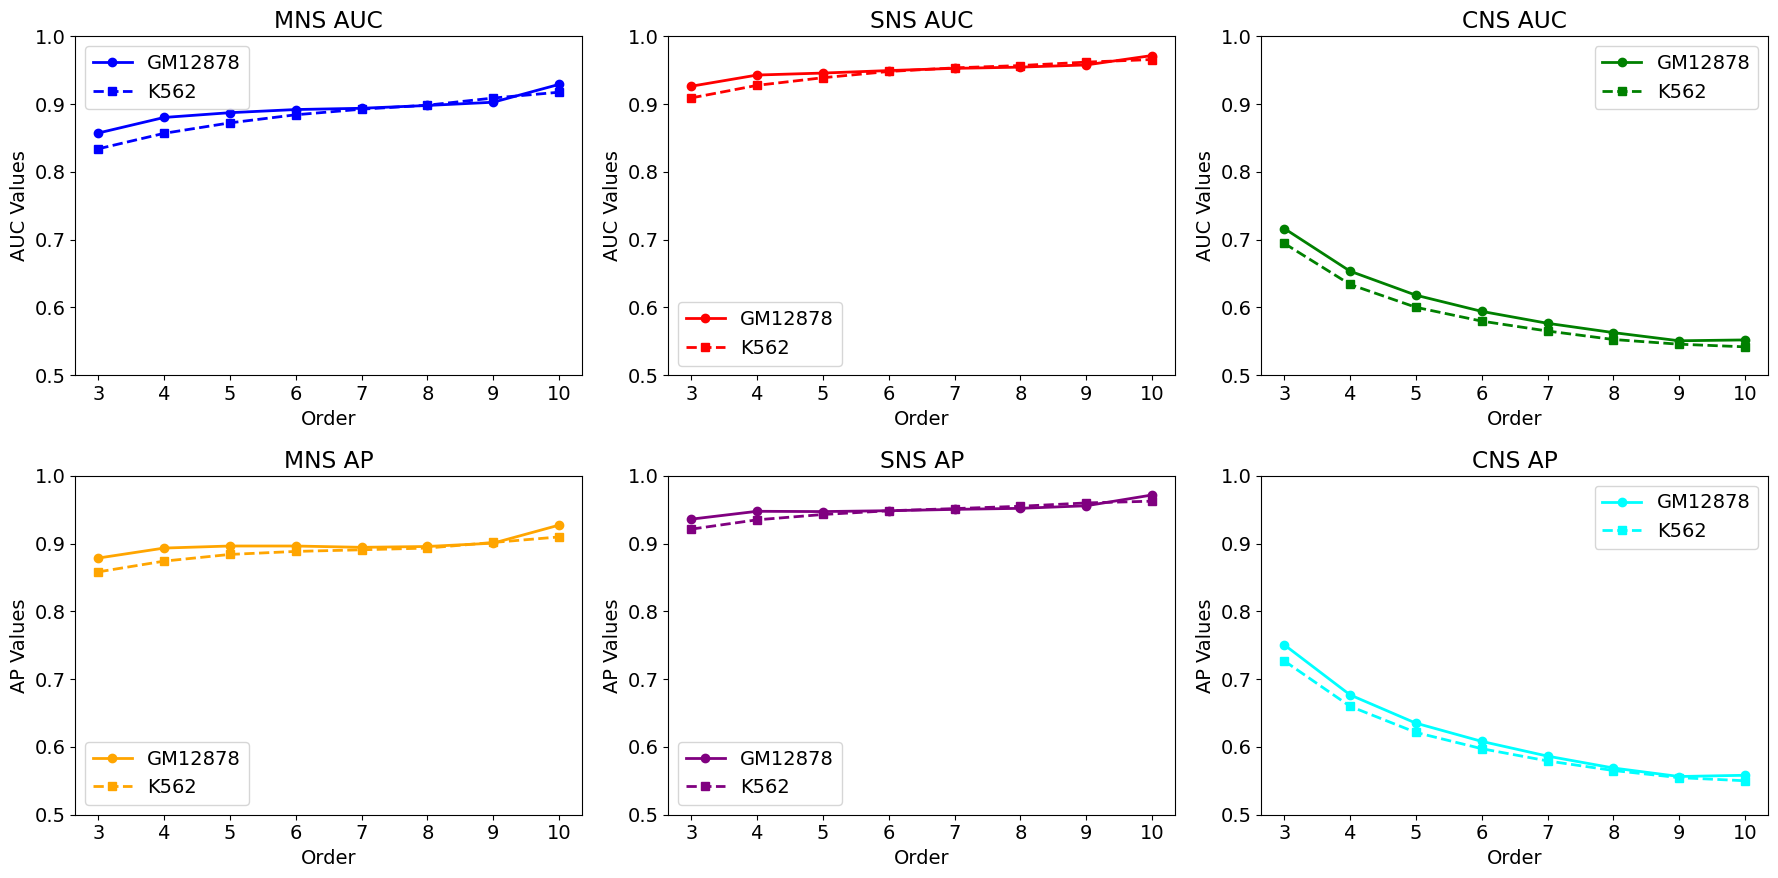

In [16]:
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 14})

# 假设这是你的数据，按照每个折线图分组
data = {
    'MNS AUC': {'x': list(range(3,11)), 'y1': gmns_auc, 'y2': kmns_auc },
    'SNS AUC': {'x': list(range(3,11)), 'y1': gsns_auc, 'y2': ksns_auc},
    'CNS AUC': {'x': list(range(3,11)), 'y1': gcns_auc, 'y2': kcns_auc},
    'MNS AP': {'x': list(range(3,11)), 'y1': gmns_ap, 'y2': kmns_ap },
    'SNS AP': {'x': list(range(3,11)), 'y1': gsns_ap, 'y2': ksns_ap},
    'CNS AP': {'x': list(range(3,11)), 'y1': gcns_ap, 'y2': kcns_ap},
}

# 创建一个包含6个子图的画布
fig, axs = plt.subplots(2, 3, figsize=(12*1.5, 9))

axs = axs.flatten()  # 将二维数组展平成一维以便操作

colors = ['blue', 'red', 'green', 'orange', 'purple', 'cyan']  # 自定义颜色列表

# 遍历数据并画图
for i, (group, values) in enumerate(data.items()):
    ax = axs[i]
    x = values['x']
    y1 = values['y1']
    y2 = values['y2']
    
    # 绘制第一条折线
    ax.plot(x, y1, marker='o', linestyle='-', color=colors[i], linewidth=2, label='GM12878')
    
    # 绘制第二条折线
    ax.plot(x, y2, marker='s', linestyle='--', color=colors[i], linewidth=2, label='K562')
    
    # 设置标题和标签
    ax.set_title(group)
    ax.set_xlabel('Order')
    ax.set_xticks(list(range(3,11)))
    ax.set_ylim(0.5,1)
    
    if i >= 3:
        ax.set_ylabel('AP Values')
    else:
        ax.set_ylabel('AUC Values')
    
    # 添加图例
    ax.legend()

# 调整布局，防止重叠
plt.tight_layout()

plt.savefig('order1.png', dpi=300)

plt.show()


In [21]:
with open("GM12878_order_cross","rb") as f:
     GM12878_order = pickle.load(f)

In [22]:
with open("K562_order_cross","rb") as f:
     K562_order = pickle.load(f)

In [23]:
b = []
for k, v in GM12878_order.items():
    a = np.mean(v, axis = 1)
    b.append(a)

b = np.array(b).T

cgmns_auc = b[0]
cgsns_auc = b[1]
cgcns_auc = b[2]
cgmns_ap = b[3]
cgsns_ap = b[4]
cgcns_ap = b[5]

In [24]:
b = []
for k, v in K562_order.items():
    a = np.mean(v, axis = 1)
    b.append(a)

b = np.array(b).T

ckmns_auc = b[0]
cksns_auc = b[1]
ckcns_auc = b[2]
ckmns_ap = b[3]
cksns_ap = b[4]
ckcns_ap = b[5]

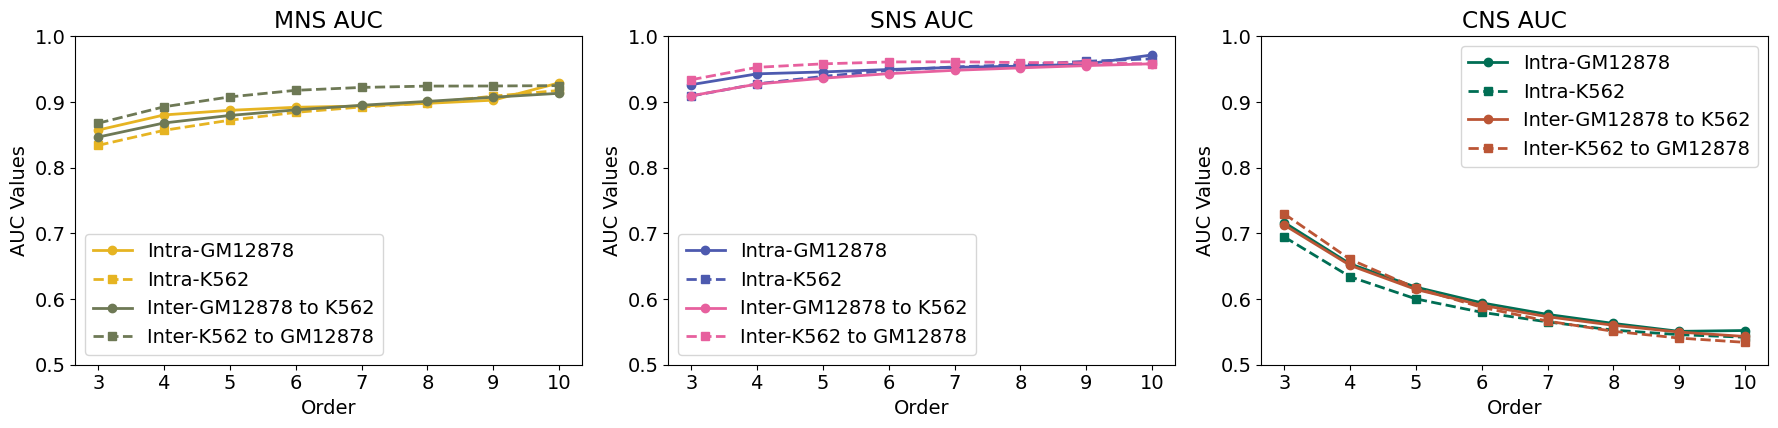

In [42]:
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 14})

# 假设这是你的数据，按照每个折线图分组
data = {
    'MNS AUC': {'x': list(range(3,11)), 'y1': gmns_auc, 'y2': kmns_auc, 'y3': cgmns_auc, 'y4': ckmns_auc },
    'SNS AUC': {'x': list(range(3,11)), 'y1': gsns_auc, 'y2': ksns_auc, 'y3': cgsns_auc, 'y4': cksns_auc },
    'CNS AUC': {'x': list(range(3,11)), 'y1': gcns_auc, 'y2': kcns_auc, 'y3': cgcns_auc, 'y4': ckcns_auc },
}

# 创建一个包含6个子图的画布
fig, axs = plt.subplots(1, 3, figsize=(12*1.5, 4.5))
axs = axs.flatten()  # 将二维数组展平成一维以便操作

colors = ['#e6b422', '#4d5aaf', '#006e54', '#6e7955', '#e7609e', '#bb5535']  # 自定义颜色列表

# 遍历数据并画图
for i, (group, values) in enumerate(data.items()):
    ax = axs[i]
    x = values['x']
    y1 = values['y1']
    y2 = values['y2']
    y3 = values['y3']
    y4 = values['y4']
    
    # 绘制第一条折线
    ax.plot(x, y1, marker='o', linestyle='-', color=colors[i], linewidth=2, label='Intra-GM12878')
    
    # 绘制第二条折线
    ax.plot(x, y2, marker='s', linestyle='--', color=colors[i], linewidth=2, label='Intra-K562')
    
    # 绘制第一条折线
    ax.plot(x, y3, marker='o', linestyle='-', color=colors[i+3], linewidth=2, label='Inter-GM12878 to K562')
    
    # 绘制第二条折线
    ax.plot(x, y4, marker='s', linestyle='--', color=colors[i+3], linewidth=2, label='Inter-K562 to GM12878')
    
    # 设置标题和标签
    ax.set_title(group)
    ax.set_xlabel('Order')
    ax.set_xticks(list(range(3,11)))
    ax.set_ylim(0.5,1)
    
    if i >= 3:
        ax.set_ylabel('AP Values')
    else:
        ax.set_ylabel('AUC Values')
    
    # 添加图例
    ax.legend()

# 调整布局，防止重叠
plt.tight_layout()

plt.savefig('order3.png', dpi=300)

plt.show()
